In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']

# Learn Fourier transform

In [2]:
t_limit = np.linspace(0, 1, 100) # This is in seconds

signal = 1*np.sin(2*np.pi*3*t_limit)
sampling_freq = 5 # So the frequency is in 1/seconds = Hz

What does it mean to have a sampling frequency of 10 Hz? It means every 1/10 seconds, the signal is sampled.

In [3]:
t_sampled = np.arange(0, 1, 1/sampling_freq)

print(t_sampled)

[0.  0.2 0.4 0.6 0.8]


The sampled signal is 

In [4]:
sampled_signal = 1*np.sin(2*np.pi*3*t_sampled)

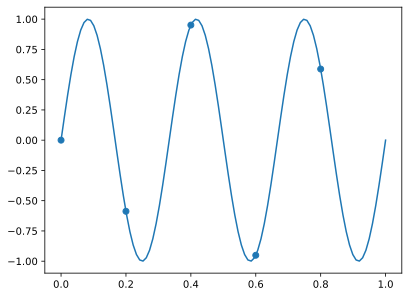

In [5]:
plt.plot(t_limit, signal)
plt.scatter(t_sampled, sampled_signal)

The Shannon-Nyquist theorem states that to accurately reconstruct a signal, its sampling rate must be at least twice the highest frequency component present in the signal.

Here the frequency of the signal is 3 Hz. So we must sample at least at 6 Hz. Here we're using 5, so we should not see 3 Hz in the frequency domain.

In [6]:
freq_sampled_signal = np.fft.fft(sampled_signal)

print(len(freq_sampled_signal))
freq_sampled_signal

5


array([ 8.88178420e-16+0.00000000e+00j, -9.79178973e-17+6.66133815e-16j,
       -3.46171313e-16+2.50000000e+00j, -3.46171313e-16-2.50000000e+00j,
       -9.79178973e-17-6.66133815e-16j])

In [7]:
freq_sampled_signal.size

5

Ok. That's the spectral part. What about the range of frequencies? When you take the FFT of a sampled signal with $N$ samples and a sampling frequency of $f_s$, the mapping is as follow:

1. The FFF result has $N$ points. In this case 5.
3. The resolution is $\Delta f = f_s/N$. 
4. The frequencies associated with each FFT bin are given by `np.fft.fftfreq(N, d=1/f_s)`. `d` is called the sampling period. 
5. The meaningful frequency range is only up to the Nyquist frequency $f_{Ny}=f_s/2$.

In [8]:
freqs = np.fft.fftfreq(freq_sampled_signal.size, d=1/sampling_freq) # This is one way of creating the array

In [9]:
sampling_freq

5

<StemContainer object of 3 artists>

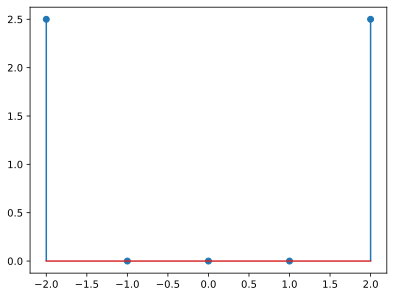

In [10]:
plt.stem(freqs, np.abs(freq_sampled_signal))

To correct, sample at 7 Hz. At exactly 6 Hz you get all zeros, not good. Edge case.

In [11]:
sampling_freq = 7
t_sampled = np.arange(0, 1, 1/sampling_freq)

print(t_sampled)

[0.         0.14285714 0.28571429 0.42857143 0.57142857 0.71428571
 0.85714286]


<StemContainer object of 3 artists>

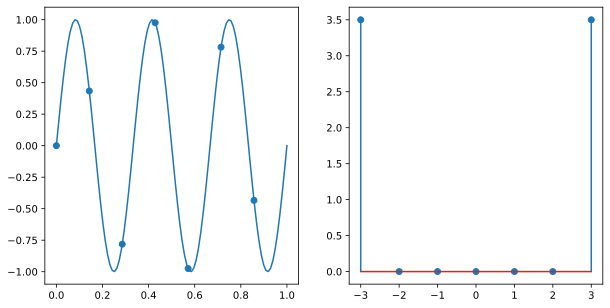

In [12]:
sampled_signal = 1*np.sin(2*np.pi*3*t_sampled)
fft_sampled_signal = np.fft.fft(sampled_signal)
freqs = np.fft.fftfreq(fft_sampled_signal.size, d=1/sampling_freq)

fig, axes = plt.subplots(ncols=2, figsize=(10, 5))

axes[0].plot(t_limit, signal)
axes[0].scatter(t_sampled, sampled_signal)
axes[1].stem(freqs, np.abs(fft_sampled_signal))

Now we try to play around with this. Let's say we suspect that the highest frequency in the signal is 20 Hz. We must therefore sampling at 40 Hz mimimum.

In [13]:
sampling_freq = 40
t_sampled = np.arange(0, 1, 1/sampling_freq)

print(t_sampled)

[0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575
 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875
 0.9   0.925 0.95  0.975]


<StemContainer object of 3 artists>

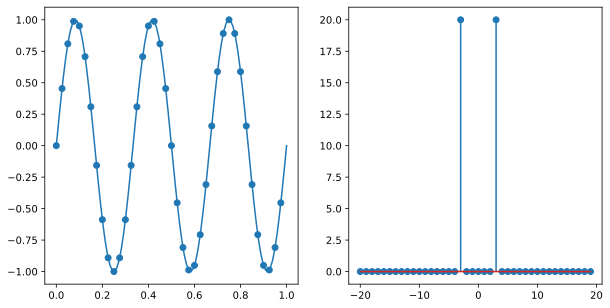

In [14]:
sampled_signal = 1*np.sin(2*np.pi*3*t_sampled)
fft_sampled_signal = np.fft.fft(sampled_signal)
freqs = np.fft.fftfreq(fft_sampled_signal.size, d=1/sampling_freq)

fig, axes = plt.subplots(ncols=2, figsize=(10, 5))

axes[0].plot(t_limit, signal)
axes[0].scatter(t_sampled, sampled_signal)
axes[1].stem(freqs, np.abs(fft_sampled_signal))

In [15]:
freqs

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19., -20., -19.,
       -18., -17., -16., -15., -14., -13., -12., -11., -10.,  -9.,  -8.,
        -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.])

We get two peaks around -3 and 3. Sure. Can we increase the resolution? That's decreasing the bin width. $\Delta f=kf_s/N$. We want to keep the same sampling frequency, so we can either

1. Increase the signal in the time domain, that's increasing $N$.
2. Padding zeroes. This also increases $N$, but we only get a visual effect. There's no new information.

In [16]:
sampling_freq = 40
t_sampled = np.arange(0, 10, 1/sampling_freq)

print(t_sampled)

[0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575
 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875
 0.9   0.925 0.95  0.975 1.    1.025 1.05  1.075 1.1   1.125 1.15  1.175
 1.2   1.225 1.25  1.275 1.3   1.325 1.35  1.375 1.4   1.425 1.45  1.475
 1.5   1.525 1.55  1.575 1.6   1.625 1.65  1.675 1.7   1.725 1.75  1.775
 1.8   1.825 1.85  1.875 1.9   1.925 1.95  1.975 2.    2.025 2.05  2.075
 2.1   2.125 2.15  2.175 2.2   2.225 2.25  2.275 2.3   2.325 2.35  2.375
 2.4   2.425 2.45  2.475 2.5   2.525 2.55  2.575 2.6   2.625 2.65  2.675
 2.7   2.725 2.75  2.775 2.8   2.825 2.85  2.875 2.9   2.925 2.95  2.975
 3.    3.025 3.05  3.075 3.1   3.125 3.15  3.175 3.2   3.225 3.25  3.275
 3.3   3.325 3.35  3.375 3.4   3.425 3.45  3.475 3.5   3.525 3.55  3.575
 3.6   3.625 3.65  3.675 3.7   3.725 3.75  3.775 3.8   3.825 3.85  3.875
 3.9   3.925 3.95  3.975 4.    4.025 4.05  4.075 4.

<StemContainer object of 3 artists>

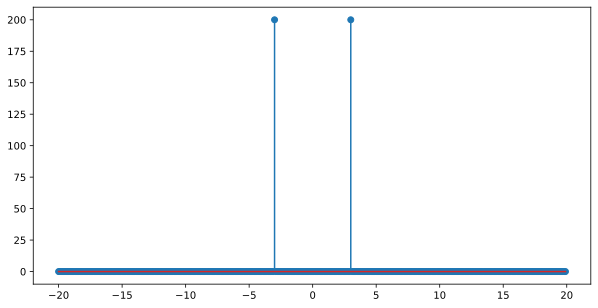

In [17]:
sampled_signal = 1*np.sin(2*np.pi*3*t_sampled)
fft_sampled_signal = np.fft.fft(sampled_signal)
freqs = np.fft.fftfreq(fft_sampled_signal.size, d=1/sampling_freq)

fig, ax = plt.subplots(figsize=(10, 5))
ax.stem(freqs, np.abs(fft_sampled_signal))

# One-sided FFT

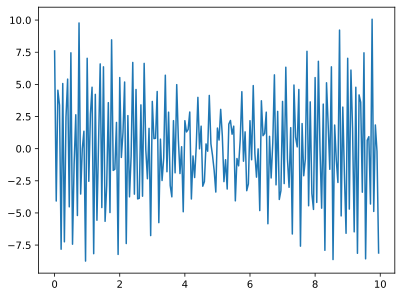

In [18]:
sampling_frequency = 20
t_sampled = np.arange(0, 10, 1/sampling_frequency)
signal = 2.5*np.sin(2*np.pi*3*t_sampled) + 4.6*np.cos(2*np.pi*8*t_sampled) + 3*np.cos(2*np.pi*7.9*t_sampled) 

plt.plot(t_sampled, signal)

In [19]:
fft_signal = np.fft.fft(signal)
freqs = np.fft.fftfreq(fft_signal.size, d=1/sampling_frequency)
magnitude = np.abs(fft_signal)/fft_signal.size
magnitude[1:-1] *= 2

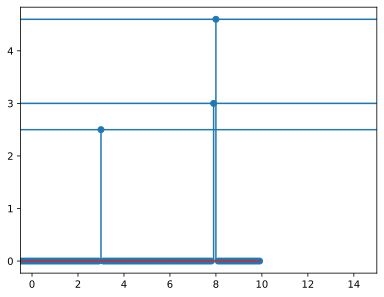

In [20]:
plt.stem(freqs, magnitude)
plt.xlim([-0.5, 15])
plt.axhline(2.5)
plt.axhline(3)
plt.axhline(4.6)

# Transition back to transmon

The functional form of the drive is
\begin{align}
\mathcal{E}=\Omega_x(t)\cos(\omega_d t+\phi_d)+\Omega_y(t)\sin(\omega_d t+\phi_d),\\
\Omega_x(t)=A\dfrac{\exp\left[-\frac{(t-t_g/2)^2}{2\sigma^2}\right]-\exp\left[-\frac{t_g^2}{8\sigma^2}\right]}{1-\exp\left[-\frac{t_g^2}{8\sigma^2}\right]}
\end{align}

In [21]:
import scipy.special as scs 

def Omega_x(t, args):
    A = args['A']
    tg = args['tg']
    sigma = args['sigma']
    if 0 < t < tg:
        return A*(np.exp(-(t-tg/2)**2/(2*sigma**2))-np.exp(-tg**2/(8*sigma**2)))/(1-np.exp(-tg**2/(8*sigma**2)))
    else: 
        return 0

In [23]:
def myfftshift(signal, sampling_freq):
    fft_signal = np.fft.fftshift(np.fft.fft(signal))
    freqs = np.fft.fftshift(np.fft.fftfreq(fft_signal.size, d=1/sampling_freq))
    magnitude = np.abs(fft_signal)/fft_signal.size
    magnitude[1:-1] *= 2
    
    return freqs, magnitude

\begin{align}
\dot{\Omega}_x(t)
= -\frac{A\,(t-\tfrac{t_g}{2})}{\sigma^2\left(1-e^{-t_g^2/(8\sigma^2)}\right)}
\,\exp\!\left[-\frac{(t-\tfrac{t_g}{2})^2}{2\sigma^2}\right]
\end{align}

In [24]:
def Omega_y(t, args):
    beta = args['beta']
    A = args['A']
    tg = args['tg']
    sigma = args['sigma']
    
    if 0 <= t <= tg:
        # window = 1*np.sin(np.pi * t / tg)**2
        window = 1
        gauss = np.exp(-(t - tg/2)**2 / (2 * sigma**2))
        norm = 1 - np.exp(-tg**2 / (8 * sigma**2))
        return -(beta/(2*np.pi*0.307)) * A * (t - tg/2) * gauss * window / (sigma**2 * norm)
    else:
        return 0.0
    
def Omega_y_norm(t, args):
    beta = args['beta']
    A = args['A']
    tg = args['tg']
    sigma = args['sigma']
    
    if 0 <= t <= tg:
        window = 1*np.sin(np.pi * t / tg)**2
        # window = 1
        gauss = np.exp(-(t - tg/2)**2 / (2 * sigma**2))
        norm = 1 - np.exp(-tg**2 / (8 * sigma**2))
        return -(beta/(2*np.pi*0.307)) * A * (t - tg/2) * gauss * window / (sigma**2 * norm)
    else:
        return 0.0

In [25]:
tg = 20
ratio = 100
xi = 4
omega_d = 4.678

In [26]:
times = np.arange(0, tg*ratio, 1/sampling_freq)
args_uncorrected = {'A': 1, 'tg': tg, 'sigma': tg/xi, 'beta': 0}
args_phase = {'A': 1, 'tg': tg, 'sigma': tg/xi, 'beta': 0.5}
args_leakage = {'A': 1, 'tg': tg, 'sigma': tg/xi, 'beta': 1} 

DRAG_uncorrected_waveform = [Omega_x(t, args_uncorrected) for t in times]
DRAG_leakage_waveform_real = [Omega_x(t, args_leakage) for t in times]
DRAG_leakage_waveform_imag = [Omega_y(t, args_leakage) for t in times]
signal_DRAG_uncorrected = [Omega_x(t, args_uncorrected)*np.cos(2*np.pi*omega_d*t)+Omega_y(t, args_uncorrected)*np.sin(2*np.pi*omega_d*t) for t in times]
signal_DRAG_phase = [Omega_x(t, args_phase)*np.cos(2*np.pi*omega_d*t)+Omega_y(t, args_phase)*np.sin(2*np.pi*omega_d*t) for t in times]
signal_DRAG_leakage = [Omega_x(t, args_leakage)*np.cos(2*np.pi*omega_d*t)+Omega_y(t, args_leakage)*np.sin(2*np.pi*omega_d*t) for t in times]

(0.0, 20.0)

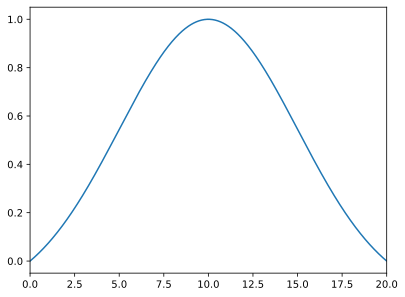

In [29]:
plt.plot(times, DRAG_uncorrected_waveform)
plt.xlim([0, 20])

(0.0, 20.0)

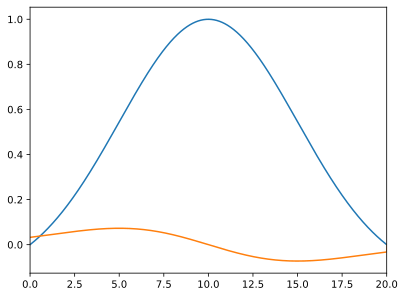

In [32]:
plt.plot(times, DRAG_leakage_waveform_real)
plt.plot(times, DRAG_leakage_waveform_imag)
plt.xlim([0, 20])

In [30]:
waveform_DRAG_X = np.array([Omega_x(t, args_uncorrected) for t in times])
waveform_DRAG_Y_phase = np.array([Omega_y_norm(t, args_phase) for t in times])
waveform_DRAG_Y_leakage = np.array([Omega_y_norm(t, args_leakage) for t in times])

In [31]:
_, magnitude_DRAG_uncorrected = myfftshift(signal_DRAG_uncorrected, sampling_freq)
_, magnitude_DRAG_phase = myfftshift(signal_DRAG_phase, sampling_freq)
freqs, magnitude_DRAG_leakage = myfftshift(signal_DRAG_leakage, sampling_freq)


freqs = freqs-4.678
freqs = freqs/0.307

In [32]:
(4.678+4.985)/2

4.8315

In [33]:
4.678+0.307/2

4.8315

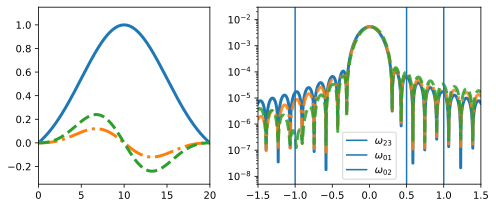

In [30]:
fig, axes = plt.subplots(
    ncols=2, 
    figsize=(7, 3),
    gridspec_kw={'width_ratios': [1, 1.3]})

axes[0].plot(times, waveform_DRAG_X, lw=3)
axes[0].plot(times, 5*waveform_DRAG_Y_phase, lw=3, linestyle='dashdot')
axes[0].plot(times, 5*waveform_DRAG_Y_leakage, lw=3, linestyle='--')
axes[0].set_xlim(0, tg)
axes[0].set_ylim(-0.35, 1.15)

axes[1].plot(freqs, magnitude_DRAG_uncorrected, lw=3)
axes[1].plot(freqs, magnitude_DRAG_phase, lw=3, linestyle='dashdot', alpha=0.85)
axes[1].plot(freqs, magnitude_DRAG_leakage, lw=3, linestyle='--', alpha=0.85)
axes[1].axvline(-1, label=r'$\omega_{23}$')
axes[1].axvline(1, label=r'$\omega_{01}$')
axes[1].axvline(0.5, label=r'$\omega_{02}$')
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(5*1e-9, 3*1e-2)
axes[1].set_yscale('log')
axes[1].legend()
fig.tight_layout()
fig.savefig('fig1d.pdf',format='pdf', bbox_inches='tight')

# $E_J/E_C$

In [34]:
EjEc = (4.985/0.307+1)**2/8

print(EjEc)

37.14265403346456


In [35]:
import scipy.constants as cte

Ec = cte.h * 0.307 * 1e9 # Joules
Ej = ( cte.h * 4.985 * 1e9 + Ec )**2 / (8*Ec)

print(Ec, Ej, Ej/Ec)

2.03420353605e-25 7.555571817315537e-24 37.142654033464545


In [36]:
import math

def e_m(m, Ec, Ej):
    em = (-1)**m * Ec * (2**(4*m+5)/math.factorial(m)) * np.sqrt(2/np.pi) * (Ej/(2*Ec))**(m/2+3/4) * np.exp(-np.sqrt(8*Ej/Ec)) 
    em_freq = em / cte.h
    em_freq_MHz = em_freq / 1e6
    return em_freq_MHz

In [37]:
e_m(0, Ec, Ej), e_m(1, Ec, Ej), e_m(2, Ec, Ej)

(np.float64(0.002288683325615982),
 np.float64(-0.157807324549313),
 np.float64(5.440497469152863))

In [38]:
import qutip as qt 

def hamiltonian(Ec, Ej, N, ng):
    """
    Return the charge qubit hamiltonian as a Qobj instance.
    """
    m = np.diag(4 * Ec * (np.arange(-N, N + 1) - ng) ** 2) + 0.5 * Ej * (
        np.diag(-np.ones(2 * N), 1) + np.diag(-np.ones(2 * N), -1)
    )
    return qt.Qobj(m)

In [51]:
N = 20
Ec_GHz = Ec/cte.h/1e9
Ej_GHz = Ej/cte.h/1e9

In [52]:
Ec_GHz

0.307

In [53]:
Ej_GHz

11.402794788273615

In [54]:
ng_vec_plus = np.linspace(-1, 1, 500)
energies_plus = np.array([hamiltonian(Ec_GHz, Ej_GHz, N, ng).eigenenergies()
                     for ng in ng_vec_plus])
ng_vec_minus = np.linspace(-0.5, 1.5, 500)
energies_minus = np.array([hamiltonian(Ec_GHz, Ej_GHz, N, ng).eigenenergies()
                     for ng in ng_vec_minus])

In [58]:
(np.max(energies_plus[:, 1])-np.min(energies_plus[:, 1]))*1e9/1e3

np.float64(126.60910525852387)

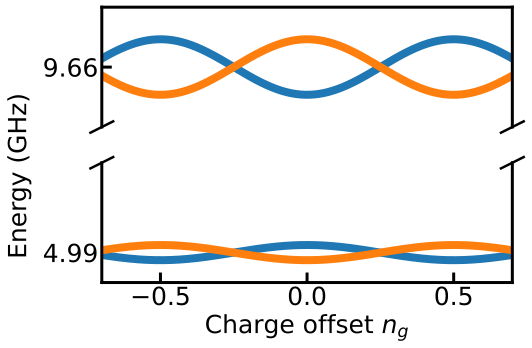

In [42]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(7.5,5))

fig.subplots_adjust(hspace=0.1)

ax1.plot(ng_vec_plus, (energies_plus[:, 2]-mean_energy_2)+9.66, lw=8, color='tab:blue')
ax2.plot(ng_vec_plus, (energies_plus[:, 1]-mean_energy_1)/1e-5/5+4.985, lw=8, color='tab:blue')
ax1.plot(ng_vec_plus, (energies_minus[:, 2]-mean_energy_2)+9.66, lw=8, color='tab:orange')
ax2.plot(ng_vec_plus, (energies_minus[:, 1]-mean_energy_1)/1e-5/5+4.985, lw=8, color='tab:orange')

ax1.spines.bottom.set_visible(False)
ax1.tick_params(axis='both', which='both', bottom=False,labelbottom=False, labelsize=25, length=10, direction='in', width=3)
ax1.set_ylim([9.66-0.0035, 9.66+0.0035])
ax1.set_yticks([9.66])

ax2.xaxis.tick_bottom()
ax2.set_ylim([-5+4.985, 15+4.985])
ax2.set_yticks([4.985])
ax2.spines.top.set_visible(False)
ax2.set_xticks([-0.5, 0, 0.5])
ax2.set_xlim([-0.7, 0.7])
ax2.set_xlabel(r'Charge offset $n_g$',fontsize=25)
ax2.tick_params(axis='both', labelsize=25, length=10, direction='in', width=3)

d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=25, lw=2.5,
              linestyle="none", color='k', mec='k', mew=2.5, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)
fig.supylabel('Energy (GHz)', fontsize=25)
for spine in ['left', 'right', 'top', 'bottom']:
    if spine in ax1.spines:
        ax1.spines[spine].set_linewidth(3.0)
    if spine in ax2.spines:
        ax2.spines[spine].set_linewidth(3.0)

fig.tight_layout()
fig.savefig('./parity.svg')

# Different durations

In [41]:
import pickle 

duration = 48
amp_start = -0.1
amp_end = 1.0
type = 'single'

with open(f'./data/rabi12/duration/{duration}_{amp_start}_{amp_end}_{type}.pkl', 'rb') as f:
    rabi_data = pickle.load(f)

In [42]:
rabi_data = np.array(rabi_data)

In [43]:
rabi_data.shape

(100, 4096)

In [44]:
amp = np.linspace(amp_start, amp_end, rabi_data.shape[0])
readout_data = []

for i in range(rabi_data.shape[0]):
    each_amp = rabi_data[i]
    each_amp_average_real = np.real(np.average(each_amp))
    readout_data.append(each_amp_average_real)

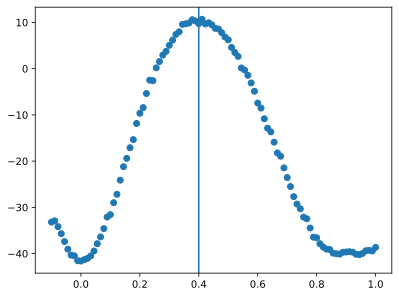

In [45]:
plt.scatter(amp, readout_data)

idx_2 = 45
plt.axvline(amp[idx_2])

(-40.0, 90.0)

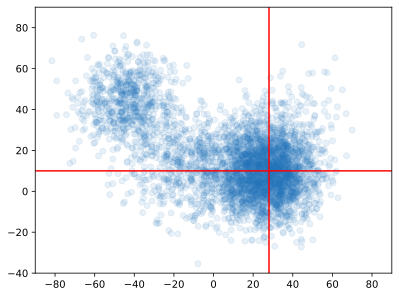

In [46]:
plt.scatter(np.real(rabi_data[idx_2]), np.imag(rabi_data[idx_2]), alpha=0.1)
plt.axvline(28, color='red')
plt.axhline(10, color='red')
plt.xlim([-90, 90])
plt.ylim([-40, 90])
# plt.savefig(f'./figures/durations/{duration}_zoomed.png')

# Leakage in APE

In [47]:
import qutip as qt

In [77]:
sigma12x = np.array([[0, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 0]])
sigma12x = qt.Qobj(sigma12x)

In [78]:
rot12_pi2_x = (-1j*(np.pi/4)*sigma12x).expm()

rot12_pi2_x

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[1.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.70710678+0.j         0.        -0.70710678j
  0.        +0.j        ]
 [0.        +0.j         0.        -0.70710678j 0.70710678+0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  1.        +0.j        ]]

In [79]:
ket0 = qt.basis(4, 0)
ket1 = qt.basis(4, 1)
ket2 = qt.basis(4, 2)
ket3 = qt.basis(4, 3)

iminus = rot12_pi2_x*ket1

iminus

Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.        +0.j        ]
 [0.70710678+0.j        ]
 [0.        -0.70710678j]
 [0.        +0.j        ]]

In [140]:
delta = 0.49

sigma12z = np.array([[0, 0, 0, 0], [0, 1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 0]])
sigma12z = qt.Qobj(sigma12z)

rot12_delta_z = (-1j*(2*delta/2)*sigma12z).expm()

rot12_delta_z

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[1.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.88233286-0.47062589j 0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.88233286+0.47062589j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  1.        +0.j        ]]

In [141]:
iminus_delta = rot12_delta_z * iminus

iminus_delta

Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.        +0.j        ]
 [0.62390355-0.33278276j]
 [0.33278276-0.62390355j]
 [0.        +0.j        ]]

In [142]:
rho = iminus_delta*iminus_delta.dag()

rho

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.5       +0.j         0.41524869+0.27851127j
  0.        +0.j        ]
 [0.        +0.j         0.41524869-0.27851127j 0.5       +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]]

In [143]:
p_leakage = 0.41

K0 = ket0*ket0.dag() + ket1*ket1.dag() + np.sqrt(1-p_leakage)*ket2*ket2.dag() + ket3*ket3.dag()
K1 = np.sqrt(p_leakage)*ket3*ket2.dag()

K0.dag()*K0 + K1.dag()*K1

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

In [144]:
rho_L = K0*rho*K0.dag() + K1*rho*K1.dag()

rho_L

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.5       +0.j         0.31895857+0.21392857j
  0.        +0.j        ]
 [0.        +0.j         0.31895857-0.21392857j 0.295     +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.205     +0.j        ]]

In [145]:
rho_L_analytical = 0.5*np.array([
    [0, 0, 0, 0],
    [0, 1, 1j*np.sqrt(1-p_leakage)*np.exp(-2*1j*delta), 0],
    [0, -1j*np.sqrt(1-p_leakage)*np.exp(2*1j*delta), 1-p_leakage, 0],
    [0, 0, 0, p_leakage]
])

qt.Qobj(rho_L_analytical)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.5       +0.j         0.31895857+0.21392857j
  0.        +0.j        ]
 [0.        +0.j         0.31895857-0.21392857j 0.295     +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.205     +0.j        ]]

In [146]:
sigma12y = np.array([[0, 0, 0, 0], [0, 0, -1j, 0], [0, 1j, 0, 0], [0, 0, 0, 0]])
sigma12y = qt.Qobj(sigma12y)
rot12_mpi2_y = (1j*(np.pi/4)*sigma12y).expm()

rot12_mpi2_y

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.          0.          0.          0.        ]
 [ 0.          0.70710678  0.70710678  0.        ]
 [ 0.         -0.70710678  0.70710678  0.        ]
 [ 0.          0.          0.          1.        ]]

In [147]:
rho_prime_L = rot12_mpi2_y*rho_L*rot12_mpi2_y.dag()

rho_prime_L

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j  0.71645857+6.40610906e-18j
  -0.1025    +2.13928568e-01j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j -0.1025    -2.13928568e-01j
   0.07854143-3.57433492e-18j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.205     +0.00000000e+00j]]

In [148]:
r = np.sqrt(1-p_leakage)
c = np.cos(2*delta)
s = np.sin(2*delta)

rho11 = 1/2-p_leakage/4+r*s/2
rho11

np.float64(0.716458567298523)

In [149]:
-p_leakage/4+1j*r*c/2

(-0.1025+0.21392856832801366j)

In [150]:
1/2-p_leakage/4-r*s/2

np.float64(0.07854143270147707)

In [151]:
p_leakage/2

0.205